
**Importations**



In [1]:
# Bibliothèques nécessaires

import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

**Préparation des données**

In [2]:
# Chargement du dataset MNIST
# 60 000 images pour l'entraînement
# 10 000 images pour le test
# Chaque image représente un chiffre de 0 à 9

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalisation des pixels : [0, 255] -> [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Ajout du canal grayscale :
# (28, 28) -> (28, 28, 1)
x_train = x_train[..., None]
x_test = x_test[..., None]

print("Train :", x_train.shape)
print("Test  :", x_test.shape)

Train : (60000, 28, 28, 1)
Test  : (10000, 28, 28, 1)


**Création du modèle**

In [3]:
# CNN volontairement simple pour servir de modèle de départ
#un seul bloc convolutionnel :  Conv2D→ReLU→MaxPooling

model = Sequential([

    Input(shape=(28, 28, 1)),    # Image d'entrée : 28×28×1


    # 1 filtre de taille 7×7
    # 28×28×1 -> 22×22×1
    Conv2D(
        filters=1,
        kernel_size=(7, 7),
        activation='relu'
    ),

    # Réduction importante de la taille spatiale
    # 22×22×1 -> 3×3×1
    MaxPooling2D(
        pool_size=(7, 7)
    ),

    # 3×3×1 -> 9 valeurs
    Flatten(),

    # 10 classes : chiffres de 0 à 9
    Dense(
        10,
        activation='softmax'
    )
])

# Configuration de l'apprentissage
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Affichage de l'architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 1)      │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150 (600.00 B)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

**Expérimentation**

In [4]:
# Entraînement du modèle
# 20 % du jeu d'entraînement est utilisé pour la validation

history = model.fit(
    x_train,
    y_train,
    epochs=3,
    validation_split=0.2
)

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4714 - loss: 1.5956 - val_accuracy: 0.7222 - val_loss: 0.9410
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7215 - loss: 0.9096 - val_accuracy: 0.7580 - val_loss: 0.7996
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7441 - loss: 0.8224 - val_accuracy: 0.7786 - val_loss: 0.7390


**Résultats et courbes**

Test loss     : 0.7393
Test accuracy : 0.772


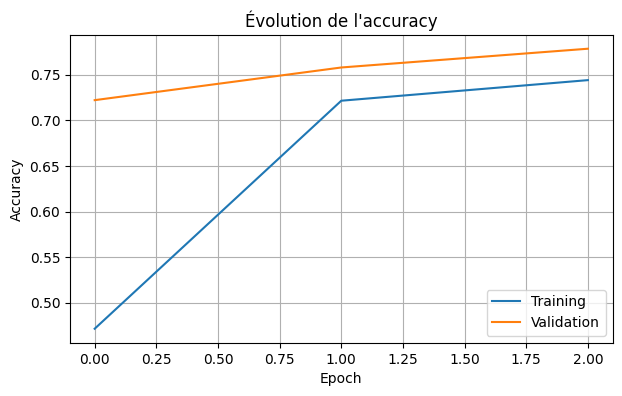

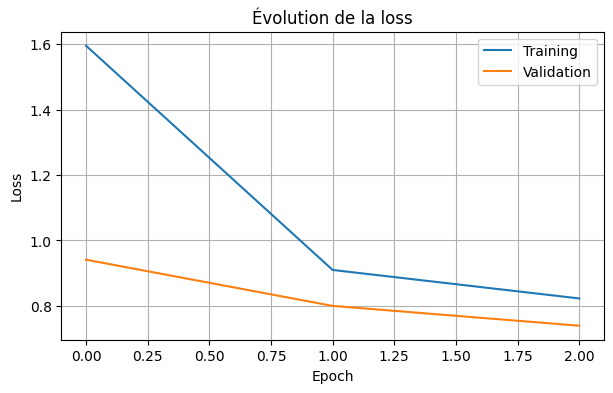

In [5]:
# Évaluation finale sur le jeu de test

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test loss     :", round(test_loss, 4))
print("Test accuracy :", round(test_accuracy, 4))


# ------------------------------------------------------------
# Courbe Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Évolution de l'accuracy")
plt.legend()
plt.grid()

plt.show()


# ------------------------------------------------------------
# Courbe Loss
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Évolution de la loss")
plt.legend()
plt.grid()

plt.show()

**Tester le modèle sur une image personnelle**

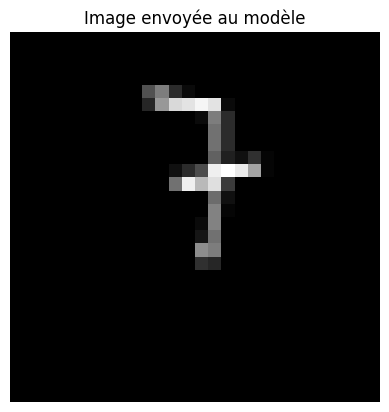

Chiffre prédit : 1
Probabilité    : 0.3985


In [8]:
# ============================================================
# 6. Tester le modèle sur une image personnelle
# ============================================================

from tkinter import Tk, filedialog
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Sélectionner une image depuis l'ordinateur
root = Tk()
root.withdraw()

filename = filedialog.askopenfilename(
    title="Sélectionner une image de chiffre manuscrit",
    filetypes=[
        ("Fichiers image", "*.png *.jpg *.jpeg"),
        ("Tous les fichiers", "*.*")
    ]
)

root.destroy()

# Vérifier si une image a été sélectionnée
if not filename:
    print("Aucune image sélectionnée.")
else:

    # Ouvrir l'image et la convertir en niveaux de gris
    img = Image.open(filename).convert('L')

    # Redimensionner l'image au format MNIST (28 × 28 pixels)
    img = img.resize((28, 28))

    # Convertir l'image en tableau NumPy
    x = np.array(img)

    # MNIST contient généralement un chiffre blanc sur un fond noir.
    # Si l'image présente un fond blanc, inverser les couleurs.
    if x.mean() > 127:
        x = 255 - x

    # Normaliser les pixels : passer de [0, 255] à [0, 1]
    x = x / 255.0

    # Adapter la forme de l'image au format attendu par le modèle :
    # (nombre d'images, hauteur, largeur, canaux)
    # Soit : (1, 28, 28, 1)
    x = x.reshape(1, 28, 28, 1)

    # Afficher l'image réellement envoyée au modèle
    plt.imshow(x[0, :, :, 0], cmap='gray')
    plt.title("Image envoyée au modèle")
    plt.axis('off')
    plt.show()

    # Effectuer la prédiction
    prediction = model.predict(x, verbose=0)

    # Identifier la classe ayant la probabilité la plus élevée
    chiffre_predit = np.argmax(prediction[0])

    # Récupérer la probabilité associée au chiffre prédit
    probabilite = prediction[0][chiffre_predit]

    print("Chiffre prédit :", chiffre_predit)
    print("Probabilité    :", round(float(probabilite), 4))

**Amélioration progressive du CNN**

*Version.0:Modèle initial*

In [11]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(1, (7, 7), activation='relu'),
    MaxPooling2D((7, 7)),
    Flatten(),
    Dense(10, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

model.summary()

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5587 - loss: 1.3239 - val_accuracy: 0.7133 - val_loss: 0.8645
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7412 - loss: 0.7932 - val_accuracy: 0.7614 - val_loss: 0.7319
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7751 - loss: 0.7079 - val_accuracy: 0.7848 - val_loss: 0.6760
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7890 - loss: 0.6692 - val_accuracy: 0.7975 - val_loss: 0.6446
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7974 - loss: 0.6497 - val_accuracy: 0.7988 - val_loss: 0.6323


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 1)      │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 452 (1.77 KB)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 302 (1.18 KB)

*Version.1:Augmenter le nombre de filtres et réduire la taille du noyau.*

In [12]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((7, 7)),
    Flatten(),
    Dense(10, activation='softmax')
])

*Version.2:Remplacer MaxPooling par une fenêtre de 2 × 2*

In [13]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(10, activation='softmax')
])

*Version.3:Ajouter un deuxième bloc de convolution*

In [14]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(10, activation='softmax')
])

*Version.4:Ajouter une couche Dense de 128 neurones*

In [15]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test),
    verbose=1
)

model.summary()

val_accuracy = max(history.history['val_accuracy'])
print("Best validation accuracy:", round(val_accuracy, 4))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9556 - loss: 0.1485 - val_accuracy: 0.9831 - val_loss: 0.0526
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.9851 - loss: 0.0483 - val_accuracy: 0.9868 - val_loss: 0.0392
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9897 - loss: 0.0335 - val_accuracy: 0.9900 - val_loss: 0.0289
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9921 - loss: 0.0249 - val_accuracy: 0.9884 - val_loss: 0.0347
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9940 - loss: 0.0188 - val_accuracy: 0.9909 - val_loss: 0.0288


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325,856 (1.24 MB)

 Trainable params: 108,618 (424.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 217,238 (848.59 KB)

Best validation accuracy: 0.9909
